Piriyadharshini N
24BAD086
RMSE: 0.3516452144212808
MAE: 0.09997831710793073
Top Recommended Movies for User 1
      movieId                                      title  \
31         32  Twelve Monkeys (a.k.a. 12 Monkeys) (1995)   
507       589          Terminator 2: Judgment Day (1991)   
659       858                      Godfather, The (1972)   
793      1036                            Die Hard (1988)   
902      1200                              Aliens (1986)   
958      1259                         Stand by Me (1986)   
1067     1387                                Jaws (1975)   
1445     1968                 Breakfast Club, The (1985)   
2078     2762                    Sixth Sense, The (1999)   
2195     2918            Ferris Bueller's Day Off (1986)   

                              genres  
31           Mystery|Sci-Fi|Thriller  
507                    Action|Sci-Fi  
659                      Crime|Drama  
793            Action|Crime|Thriller  
902   Action|Adventure|Horror|Sci

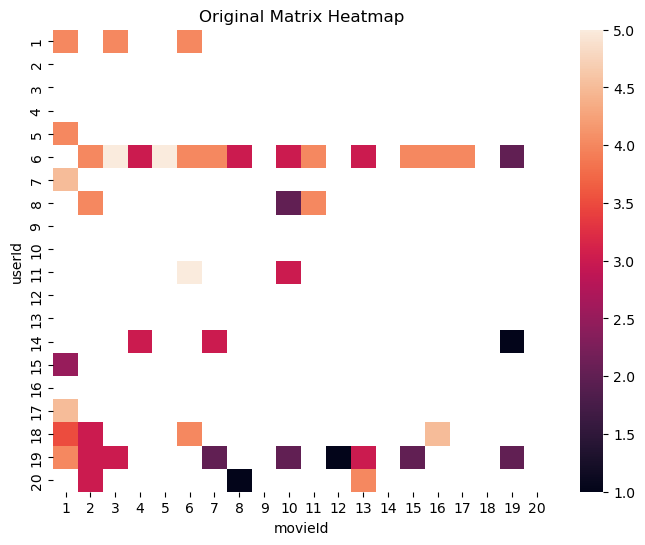

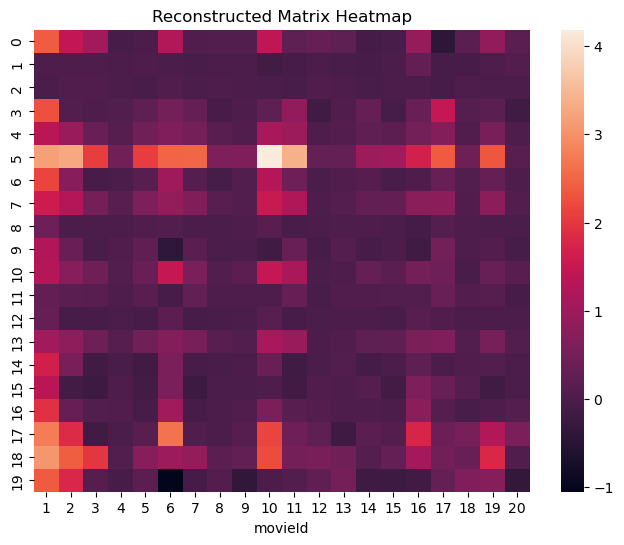

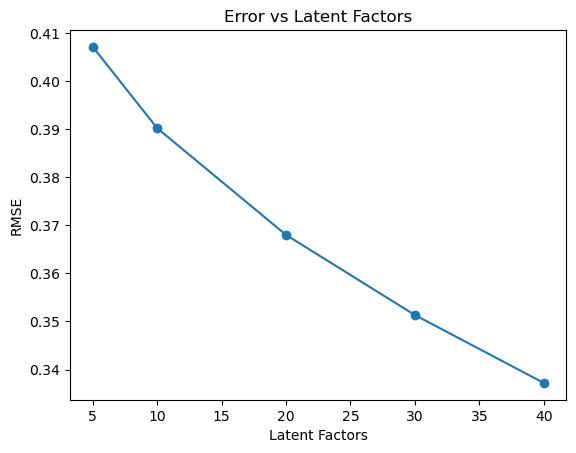

In [4]:
print("Piriyadharshini N")
print("24BAD086")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import svds
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Data preprocessing
data = ratings[['userId','movieId','rating']]

# Create user-item interaction matrix
user_item = data.pivot(index='userId', columns='movieId', values='rating')

# Fill missing values
matrix = user_item.fillna(0)

# Mean normalization
user_mean = np.mean(matrix, axis=1)
matrix_norm = matrix - user_mean.values.reshape(-1,1)

matrix_norm = matrix_norm.values

# Apply SVD
k = 20
U, sigma, Vt = svds(matrix_norm, k=k)

sigma = np.diag(sigma)

# Reconstruct matrix
reconstructed = np.dot(np.dot(U, sigma), Vt) + user_mean.values.reshape(-1,1)

predictions = pd.DataFrame(reconstructed, columns=user_item.columns)

# Evaluation
actual = user_item.fillna(0).values.flatten()
predicted = predictions.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

# Top-N Recommendation
def recommend_movies(user_id, n=10):

    user_pred = predictions.iloc[user_id-1]
    sorted_movies = user_pred.sort_values(ascending=False)

    watched = ratings[ratings.userId==user_id]['movieId']

    recommendations = sorted_movies[~sorted_movies.index.isin(watched)]

    top_movies = recommendations.head(n)

    return movies[movies.movieId.isin(top_movies.index)]

print("Top Recommended Movies for User 1")
print(recommend_movies(1))

# Heatmap visualization
plt.figure(figsize=(8,6))
sns.heatmap(user_item.iloc[:20,:20])
plt.title("Original Matrix Heatmap")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(predictions.iloc[:20,:20])
plt.title("Reconstructed Matrix Heatmap")
plt.show()

# Latent factor analysis
latent = [5,10,20,30,40]
errors = []

for k in latent:

    U,sigma,Vt = svds(matrix_norm,k=k)
    sigma = np.diag(sigma)

    recon = np.dot(np.dot(U,sigma),Vt)

    rmse_val = np.sqrt(mean_squared_error(matrix.values.flatten(),
                                          recon.flatten()))

    errors.append(rmse_val)

plt.plot(latent,errors,marker='o')
plt.xlabel("Latent Factors")
plt.ylabel("RMSE")
plt.title("Error vs Latent Factors")
plt.show()

Piriyadharshini N
24BAD086


C:\Users\piriyadharshini\anaconda3\Lib\site-packages\sklearn\decomposition\_nmf.py:1728: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 0.35966194522067546
Precision@K: 0.1
Recall@K: 0.1


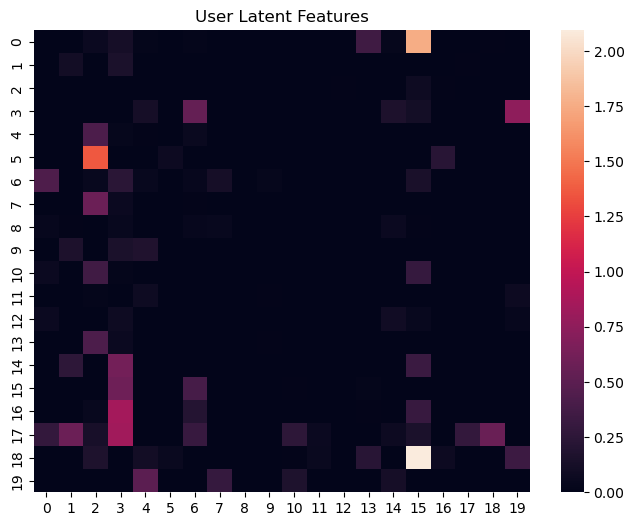

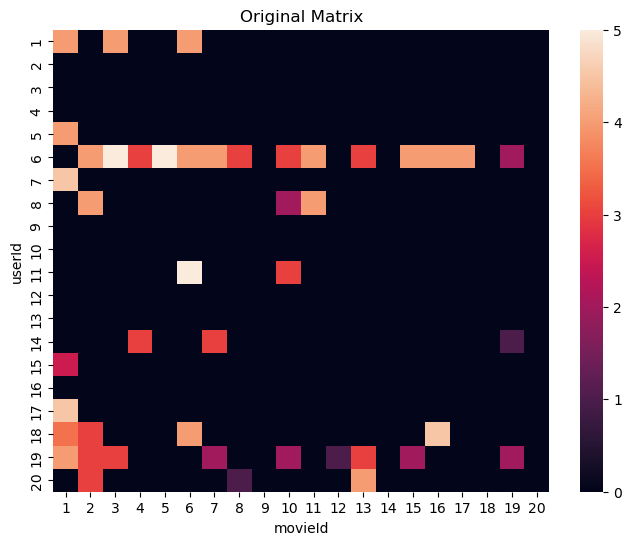

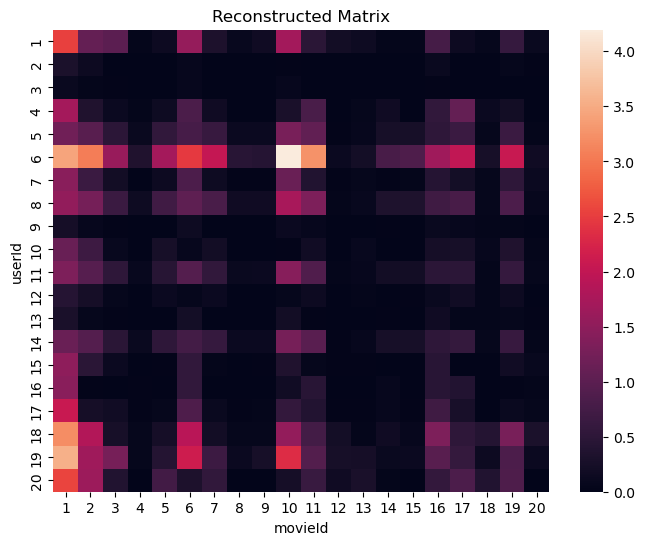

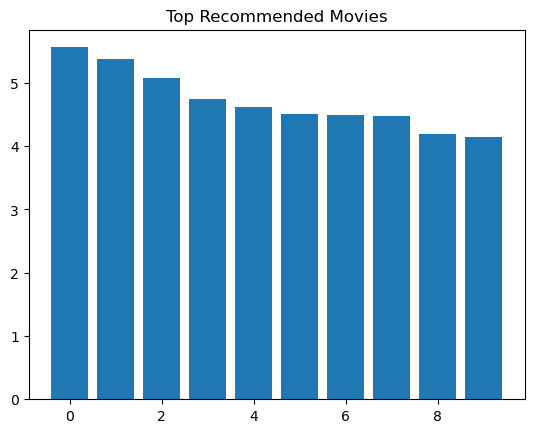

In [5]:
print("Piriyadharshini N")
print("24BAD086")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

# Load dataset
ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Create user-item matrix
user_item = ratings.pivot(index='userId', columns='movieId', values='rating')

# Handle missing values
matrix = user_item.fillna(0)

# Apply NMF
model = NMF(n_components=20, random_state=42)

user_features = model.fit_transform(matrix)
item_features = model.components_

# Reconstruct matrix
reconstructed = np.dot(user_features, item_features)

predictions = pd.DataFrame(reconstructed,
                           columns=user_item.columns,
                           index=user_item.index)

# RMSE
rmse = np.sqrt(mean_squared_error(matrix.values.flatten(),
                                  reconstructed.flatten()))

print("RMSE:", rmse)

# Precision@K and Recall@K
def precision_recall_at_k(user,k=10):

    actual = user_item.iloc[user]
    predicted = predictions.iloc[user]

    actual_top = actual.sort_values(ascending=False).head(k).index
    pred_top = predicted.sort_values(ascending=False).head(k).index

    intersection = len(set(actual_top).intersection(set(pred_top)))

    precision = intersection/k
    recall = intersection/k

    return precision,recall

p,r = precision_recall_at_k(0)

print("Precision@K:",p)
print("Recall@K:",r)

# Latent feature visualization
plt.figure(figsize=(8,6))
sns.heatmap(user_features[:20])
plt.title("User Latent Features")
plt.show()

# Reconstruction comparison
plt.figure(figsize=(8,6))
sns.heatmap(matrix.iloc[:20,:20])
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(predictions.iloc[:20,:20])
plt.title("Reconstructed Matrix")
plt.show()

# Recommendation ranking chart
top_movies = predictions.iloc[0].sort_values(ascending=False).head(10)

plt.bar(range(10),top_movies.values)
plt.title("Top Recommended Movies")
plt.show()